In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
data = pd.read_csv('/content/employee_attrition_data.csv')
data

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,Male,Marketing,Manager,9,0.586251,151,0,60132,0
1,1,53,Female,Sales,Engineer,10,0.261161,221,1,79947,0
2,2,59,Female,Marketing,Analyst,8,0.304382,184,0,46958,1
3,3,42,Female,Engineering,Manager,1,0.480779,242,0,40662,0
4,4,44,Female,Sales,Engineer,10,0.636244,229,1,74307,0
...,...,...,...,...,...,...,...,...,...,...,...
995,995,39,Female,HR,HR Specialist,3,0.377435,239,0,71403,0
996,996,50,Male,Engineering,Manager,1,0.431152,154,0,30181,1
997,997,52,Male,Engineering,Analyst,3,0.647102,206,0,64143,0
998,998,37,Female,HR,HR Specialist,2,0.304813,241,0,74383,1


In [50]:
# Mã hóa các cột phân loại
encoder = LabelEncoder()
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Department'] = encoder.fit_transform(data['Department'])
data['Job_Title'] = encoder.fit_transform(data['Job_Title'])

In [51]:
X = data.drop(columns=['Attrition', 'Employee_ID'])
y = data['Attrition']  # 'Attrition' là biến mục tiêu

In [52]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [54]:
# Huấn luyện mô hình XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [55]:
# Dự đoán trên tập kiểm tra
y_pred = xgb_model.predict(X_test)

In [56]:
# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# In ra các chỉ số đánh giá
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")

Accuracy: 0.49
Precision: 0.49
Recall: 0.50
F1 Score: 0.49
ROC-AUC Score: 0.50


In [57]:
# Lấy tầm quan trọng của các đặc trưng
importance = xgb.get_booster().get_score(importance_type='weight')  # Có thể chọn 'weight', 'gain', hoặc 'cover'
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
}).sort_values(by='Importance', ascending=False)

# Hiển thị bảng feature importance
print(importance_df)

                 Feature  Importance
0     Satisfaction_Level       603.0
1                 Salary       563.0
2  Average_Monthly_Hours       490.0
3                    Age       356.0


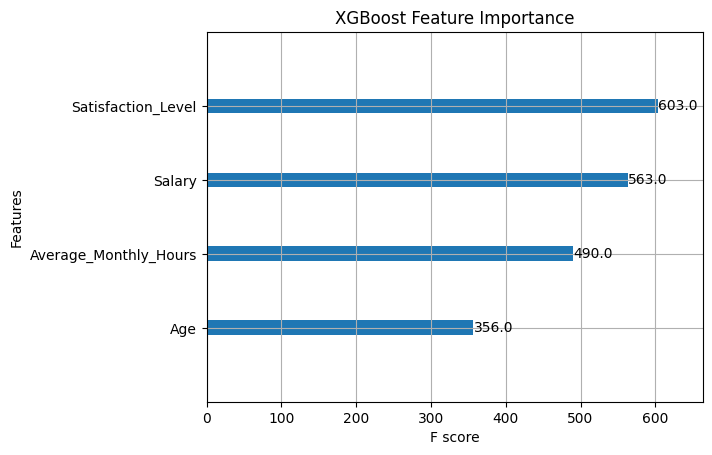

In [58]:
from xgboost import XGBClassifier, plot_importance
# Trực quan hóa
plot_importance(xgb, importance_type='weight', max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()

In [59]:
# Lọc các đặc trưng quan trọng theo ngưỡng (threshold)
threshold = 200
important_features = importance_df[importance_df['Importance'] > threshold]['Feature']
X_filtered = X[important_features]

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred = xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy after feature selection: {accuracy:.2f}")
print(f"Precision after feature selection: {precision:.2f}")
print(f"Recall after feature selection: {recall:.2f}")
print(f"F1 Score after feature selection: {f1:.2f}")


Accuracy after feature selection: 0.52
Precision after feature selection: 0.51
Recall after feature selection: 0.46
F1 Score after feature selection: 0.48


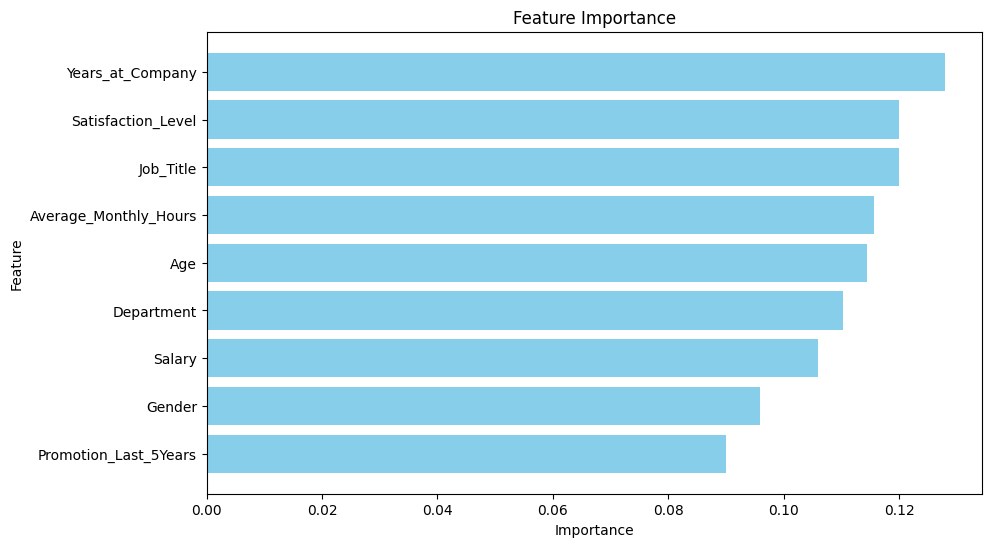

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()


In [62]:
# Lặp qua từng phòng ban và dự đoán
departments = data['Department'].unique()  # Lấy tất cả các phòng ban
attrition_by_department = {}

In [63]:
for department in departments:
    # Lọc dữ liệu cho phòng ban
    data_department = data[data['Department'] == department]

    # Xây dựng biến phụ thuộc và độc lập cho phòng ban
    X_department = data_department.drop(columns=['Attrition', 'Employee_ID'])
    y_department = data_department['Attrition']

    # Chuẩn hóa dữ liệu
    X_department_scaled = scaler.transform(X_department)

    # Dự đoán cho dữ liệu phòng ban
    y_pred_department = xgb_model.predict(X_department_scaled)

    # Tính số nhân viên nghỉ việc trong phòng ban
    attrition_count = sum(y_pred_department)
    total_employees = len(X_department)

    # Lưu kết quả vào từ điển
    attrition_by_department[department] = {
        'Total Employees': total_employees,
        'Attrition Count': attrition_count,
        'Attrition Percentage': (attrition_count / total_employees) * 100
    }

In [64]:
# Chuyển kết quả sang DataFrame để dễ dàng hiển thị
attrition_df = pd.DataFrame(attrition_by_department).T
attrition_df = attrition_df.sort_values(by='Attrition Percentage', ascending=False)

# Hiển thị kết quả
print(attrition_df)


   Total Employees  Attrition Count  Attrition Percentage
0            204.0            111.0             54.411765
1            206.0            111.0             53.883495
2            191.0             97.0             50.785340
4            209.0            106.0             50.717703
3            190.0             73.0             38.421053


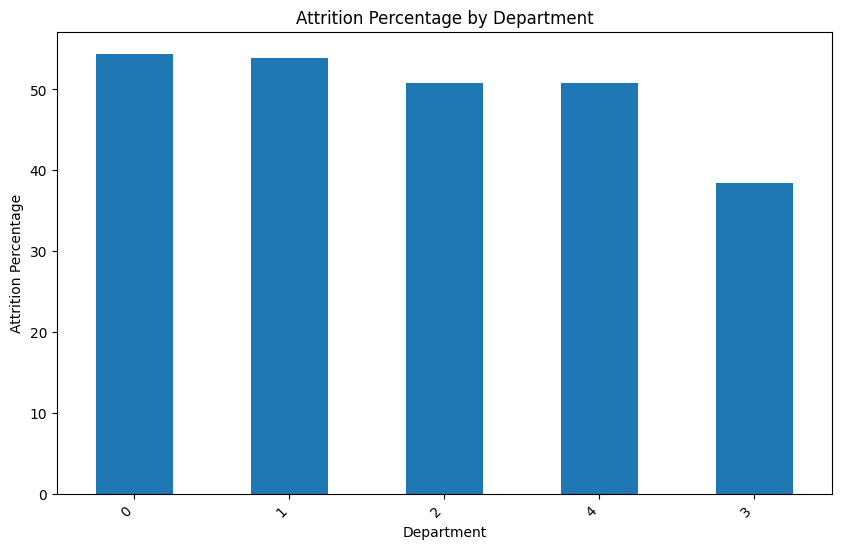

In [65]:
# Vẽ biểu đồ tỷ lệ nghỉ việc theo phòng ban
attrition_df['Attrition Percentage'].plot(kind='bar', figsize=(10, 6))
plt.title('Attrition Percentage by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Percentage')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
!jupyter nbconvert --to html '/content/OLAP_XGBoost.ipynb'